In [ ]:
# Importing Libraries
import ast # For string conversion into list object, and string conversion into dictionary object.
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # To add percentage sign to y axis ticks

plt.close('all') # close all open plots

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

In [2]:
# In plots, FuncFormatter is to format x axis ticks as £K
from matplotlib.ticker import FuncFormatter
def pounds_k(x, pos):
    return f"£{x/1000:.0f}K"

# In scatterplots, adjustText prevents overlap of point labels
from adjustText import adjust_text

In [ ]:
df_UK = df[df["job_country"] == "United Kingdom"].copy()

df_UK = df_UK.dropna(subset="salary_year_avg")

df_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,"[python, numpy, pandas, scikit-learn]","{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
9778,Senior Data Analyst,Workday HCM Senior Data Analyst (18 month FTC),"London, UK",via Ai-Jobs.net,Contractor,False,United Kingdom,2023-07-10 13:36:15,True,False,United Kingdom,year,111175.0,NaN,WPP,"[vba, python, r, oracle, sap, excel]","{'analyst_tools': ['sap', 'excel'], 'cloud': [..."
9903,Senior Data Engineer,Senior Satellite Analytics Data Engineer,"Edinburgh, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-08-10 13:34:53,False,False,United Kingdom,year,147500.0,NaN,Verisk,"[python, sql, nosql, mongodb, mongodb, elastic...","{'cloud': ['aws'], 'databases': ['mongodb', 'e..."
13764,Data Scientist,Programmatic Data Specialist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 13:22:50,False,False,United Kingdom,year,109500.0,NaN,Publicis Groupe,"[excel, powerpoint, flow]","{'analyst_tools': ['excel', 'powerpoint'], 'ot..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781461,Data Scientist,Data Scientist,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-04-04 06:31:10,False,False,United Kingdom,year,88128.0,NaN,Kuda Technologies Ltd,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
783284,Senior Data Scientist,Senior Data Scientist,"Belfast, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-28 06:14:36,False,False,United Kingdom,year,157500.0,NaN,Axiom,"[sql, r, python, aws, redshift, spark, gitlab,...","{'async': ['jira', 'confluence'], 'cloud': ['a..."
783436,Data Scientist,Insight Analyst,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-11 06:36:08,True,False,United Kingdom,year,72900.0,NaN,Xiatech,"[html, python, css, javascript, sql, bigquery,...","{'analyst_tools': ['tableau'], 'async': ['jira..."
783598,Data Engineer,Data Engineer,"London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-05-02 06:18:42,False,False,United Kingdom,year,96773.0,NaN,Prevail,"[python, java, scala, c#, r, redshift, aws]","{'cloud': ['redshift', 'aws'], 'programming': ..."


# Analyse and Plot Scatter plot

In [19]:
df_UK_copy = df_UK.copy()

In [20]:
# This essential wrapper function checks if there are strings in column job_type_skills and catches if there are na values
# Essential when running ast.literal_eval on column as it contains na values
def safe_parse_dict(val):
    # Only parse if the value is a non-null string
    if pd.notna(val) and isinstance(val, str):
        return ast.literal_eval(val)
    # Return an empty dictionary (or None) if the data is missing
    return {} 

df_UK_copy["job_type_skills"] = df_UK_copy["job_type_skills"].apply(safe_parse_dict)

In [28]:
df_UK_copy[["job_title_short", "job_type_skills"]]

,job_title_short,job_type_skills
1107,Data Scientist,"{'libraries': ['numpy', 'pandas', 'scikit-lear..."
2602,Data Analyst,"{'analyst_tools': ['excel', 'word', 'outlook']}"
9778,Senior Data Analyst,"{'analyst_tools': ['sap', 'excel'], 'cloud': [..."
9903,Senior Data Engineer,"{'cloud': ['aws'], 'databases': ['mongodb', 'e..."
13764,Data Scientist,"{'analyst_tools': ['excel', 'powerpoint'], 'ot..."
...,...,...
781461,Data Scientist,"{'cloud': ['gcp'], 'programming': ['python', '..."
783284,Senior Data Scientist,"{'async': ['jira', 'confluence'], 'cloud': ['a..."
783436,Data Scientist,"{'analyst_tools': ['tableau'], 'async': ['jira..."
783598,Data Engineer,"{'cloud': ['redshift', 'aws'], 'programming': ..."


Explode the dataframe by job_type_skills


In [ ]:
# 1. Convert the dictionary into a list of (key, value) pairs
# This is because  the dictionary cannot be exploded
df_UK_copy["skills_tuples"] = df_UK_copy["job_type_skills"].apply(lambda d: list(d.items()))

# 2. Explode the tuples into individual rows (one row per category)
df_UK_exploded = df_UK_copy.explode("skills_tuples")

# 3. Drop rows where there were no skills (empty dictionaries resulting in NaN/None)
df_UK_exploded = df_UK_exploded.dropna(subset=["skills_tuples"])

# 4. Unpack the tuples into two new columns: 'skill_type' and 'job_skills'
df_UK_exploded[["skill_type", "job_skills"]] = pd.DataFrame(
    df_UK_exploded["skills_tuples"].tolist(), 
    index=df_UK_exploded.index
)

# 5. Explode the actual list of skills so each specific skill gets its own row
df_UK_exploded = df_UK_exploded.explode("job_skills")

# 6. Drop the temporary tuple column to keep the DataFrame clean
df_UK_exploded = df_UK_exploded.drop(columns=["skills_tuples"])

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skill_type
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,numpy,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,pandas,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,scikit-learn,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,python,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",programming
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,excel,"{'analyst_tools': ['excel', 'word', 'outlook']}",analyst_tools
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,git,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",other
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,docker,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",other
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,python,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",programming
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,sql,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",programming


In [54]:
target_roles = ["Data Scientist", "Data Engineer", "Data Analyst"]

In [55]:
# 1. Filter for your target roles and ensure valid data exists
df_filtered = df_UK_exploded[
    df_UK_exploded["job_title_short"].isin(target_roles)
].dropna(subset=["salary_year_avg", "skill_type"])

In [68]:
df_filtered

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,skill_type
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,numpy,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,pandas,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,scikit-learn,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",libraries
1107,Data Scientist,"Data Scientist, Customer AI Engineering","London, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-06-20 13:12:50,False,False,United Kingdom,year,157500.0,NaN,Tractable,python,"{'libraries': ['numpy', 'pandas', 'scikit-lear...",programming
2602,Data Analyst,Admin & Data Analyst,United Kingdom,via Ai-Jobs.net,Full-time,False,United Kingdom,2023-02-10 13:55:49,False,False,United Kingdom,year,51014.0,NaN,Catch22,excel,"{'analyst_tools': ['excel', 'word', 'outlook']}",analyst_tools
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,git,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",other
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,docker,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",other
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,python,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",programming
783748,Data Engineer,Data Engineer,"Cambridge, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-07-22 06:16:12,False,False,United Kingdom,year,96773.0,NaN,Origin Sciences,sql,"{'cloud': ['aws'], 'libraries': ['pandas'], 'o...",programming


In [ ]:
df_UK_group = (df_filtered.groupby(["job_title_short", "skill_type"])["salary_year_avg"]
    .agg(median_salary="median", job_count="count")
    .reset_index()
)

df_UK_group["percentage"] = (df_UK_group["job_count"] / len(df_UK_copy)) * 100

# df_UK_group.sort_values(by="percentage", ascending=False)

df_UK_group

,job_title_short,skill_type,median_salary,job_count,percentage
0,Data Analyst,analyst_tools,80850.00,81,28.222997
1,Data Analyst,async,75550.00,3,1.045296
2,Data Analyst,cloud,98500.00,22,7.665505
3,Data Analyst,databases,165000.00,10,3.484321
4,Data Analyst,libraries,114657.50,14,4.878049
5,Data Analyst,os,53014.00,1,0.348432
6,Data Analyst,other,81000.00,6,2.090592
7,Data Analyst,programming,89100.00,100,34.843206
8,Data Analyst,sync,89100.00,1,0.348432
9,Data Analyst,webframeworks,104757.00,2,0.696864


With adjust text to prevent overlapping points and add pointing arrows if need be (Google Gemini assitance used)

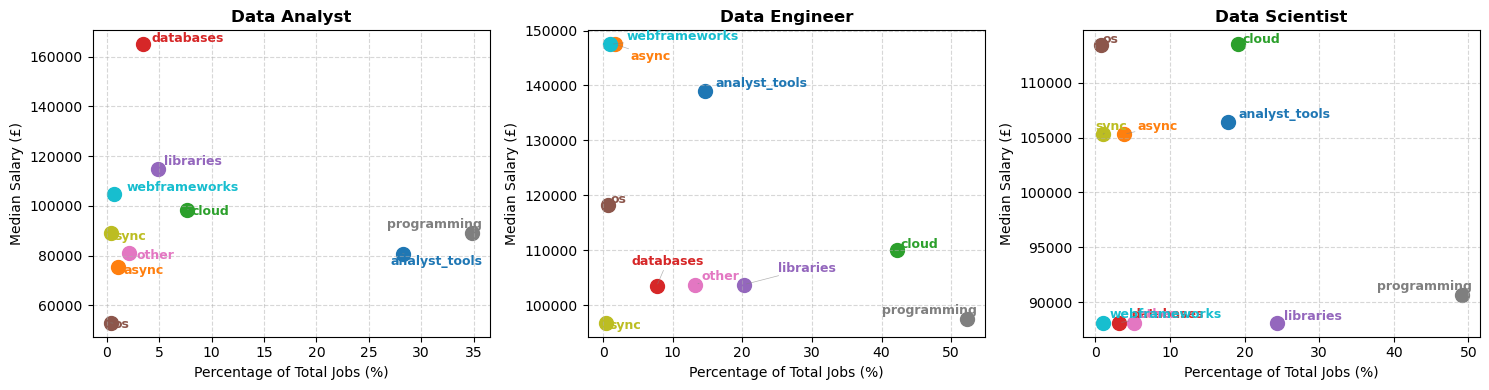

In [78]:
# 1. MAP COLOURS AND SELECT DATA
# Get a list of all unique skill categories from the DataFrame
unique_skills = df_UK_group["skill_type"].unique()

# Create a distinct colour palette (using 'tab10') with enough colours for each unique skill (it equals to 10)
colors = sns.color_palette("tab10", len(unique_skills))

# Pair each unique skill with a colour and store it in a lookup dictionary
# zip() 'zips' the skill and colour together into a key value pair
skill_color_map = dict(zip(unique_skills, colors))

# Get all unique job titles from the data (since there are exactly 3 in the table)
job_titles = df_UK_group["job_title_short"].unique()


# 2. CREATE THE GRAPH GRID
# Initialize a layout with 1 row and 3 columns of subplots (exactly 3 plot areas)
# 'axes' becomes a 1D array containing the 3 blank plotting spaces
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# 3. GENERATE THE PLOTS
# Simultaneously loop through the 3 blank plot windows and the 3 job titles
for ax, title in zip(axes, job_titles):
    
    # Filter the main DataFrame to get data only relevant to the current job title
    sub_df = df_UK_group[df_UK_group["job_title_short"] == title]
    
    # Create an empty list to keep track of text labels added to this specific subplot
    texts = []
    
    # Loop row-by-row through the filtered data for this specific job title
    for _, row in sub_df.iterrows():
        # Look up the predefined, consistent colour for this specific skill type
        point_color = skill_color_map[row["skill_type"]]
        
        # Draw a single dot on the graph based on percentage (X) and median salary (Y)
        ax.scatter(row["percentage"], row["median_salary"], color=point_color, s=100)
        
        # Place text directly over the dot using coordinates (X, Y) and the skill name string
        txt = ax.text(row["percentage"], row["median_salary"], row["skill_type"], 
                      color=point_color, fontsize=9, weight="bold")
        
        # Save this text object to our list so we can adjust it later
        texts.append(txt)
    
    # Apply standard labels, a title, and a background grid to the current subplot
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Percentage of Total Jobs (%)")
    ax.set_ylabel("Median Salary (£)")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # 4. RESOLVE LABEL OVERLAPS
    # Automatically nudge overlapping labels apart and draw thin gray connecting lines back to the dots
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6))

# Clean up layout spacing to prevent titles and axis labels from clipping or overlapping
plt.tight_layout()
